In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
df['total_bill'] = df['total_bill']
df['tip'] = df['tip']

# Create fake "income" & "spending"
df['income'] = df['total_bill'] * 10
df['spending_score'] = df['tip'] * 10

df = df[['income', 'spending_score']]
df.head()

,income,spending_score
0,169.9,10.1
1,103.4,16.6
2,210.1,35.0
3,236.8,33.1
4,245.9,36.1


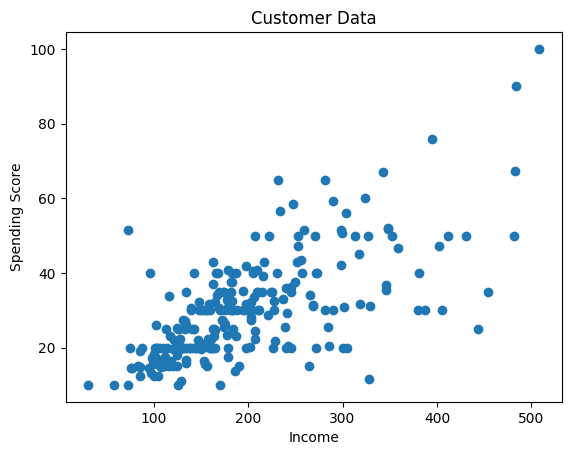

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df['income'], df['spending_score'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Data")
plt.show()

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(df)

df['cluster'] = kmeans.labels_

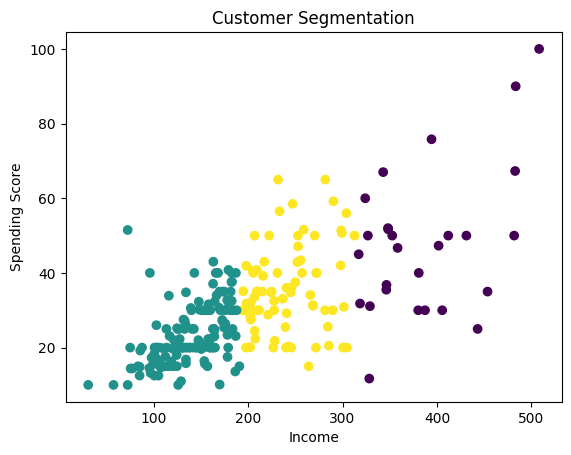

In [5]:
plt.scatter(df['income'], df['spending_score'], c=df['cluster'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()

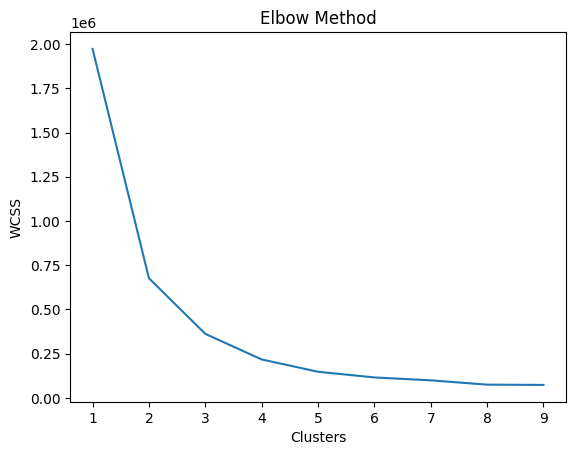

In [6]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [7]:
df['segment'] = df['cluster'].map({
    0: "Low Value",
    1: "Mid Value",
    2: "High Value"
})

In [8]:
df.head()

,income,spending_score,cluster,segment
0,169.9,10.1,1,Mid Value
1,103.4,16.6,1,Mid Value
2,210.1,35.0,2,High Value
3,236.8,33.1,2,High Value
4,245.9,36.1,2,High Value
